### 1. Импорты

In [1]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

### 2. Загрузка данных

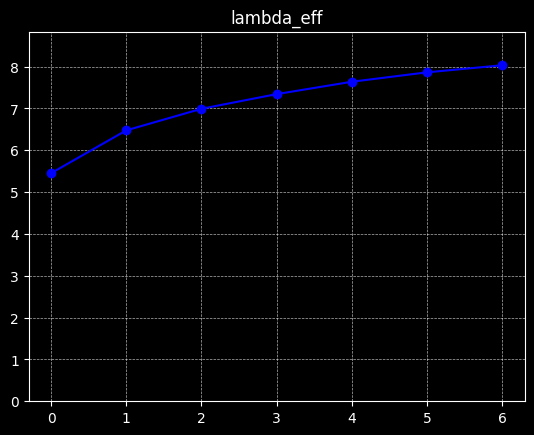

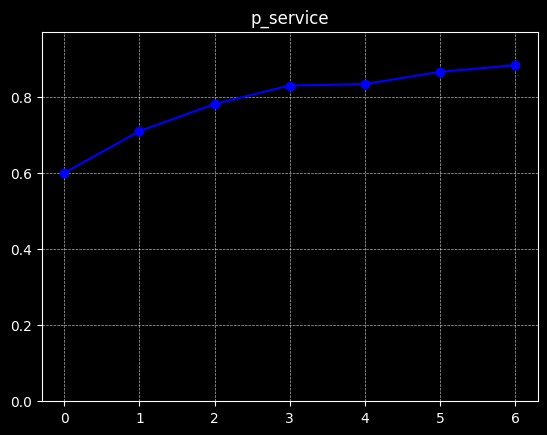

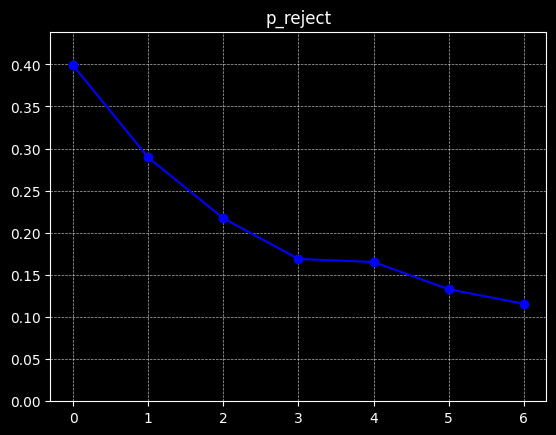

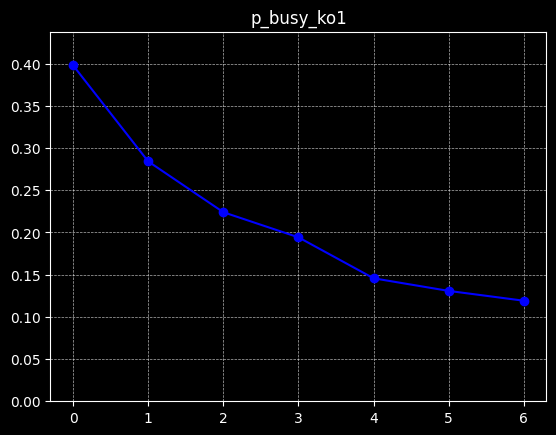

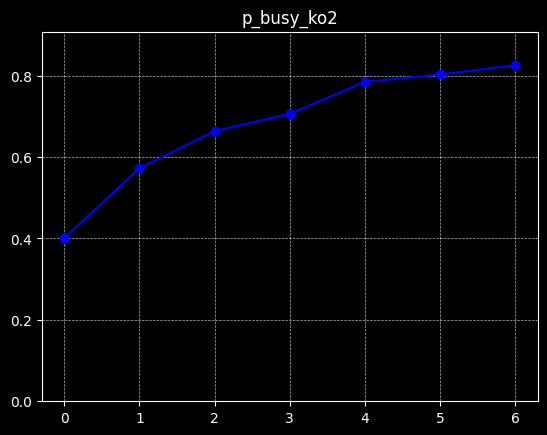

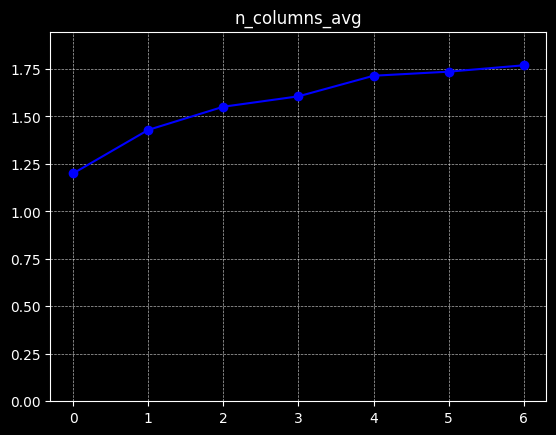

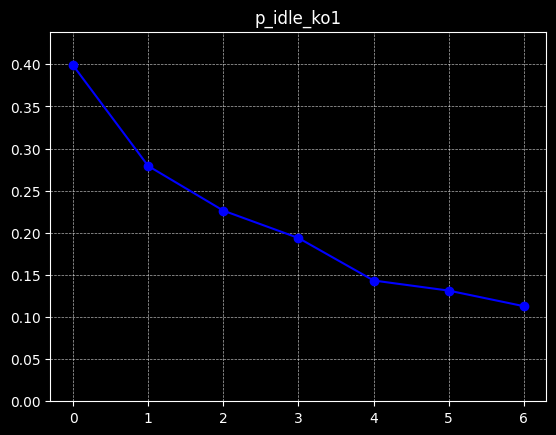

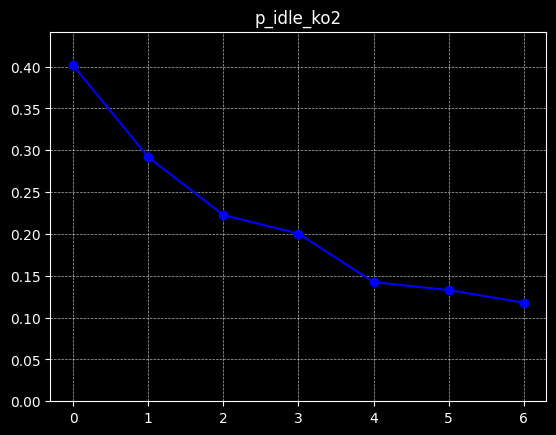

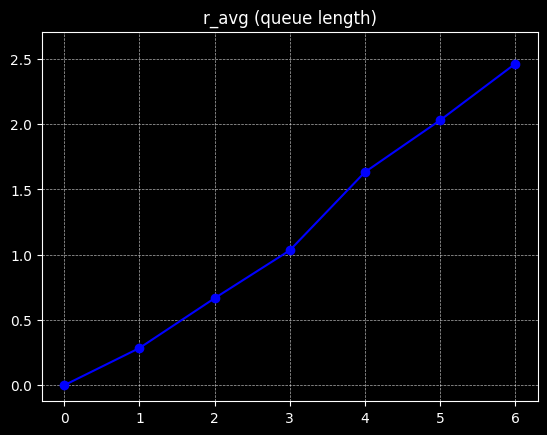

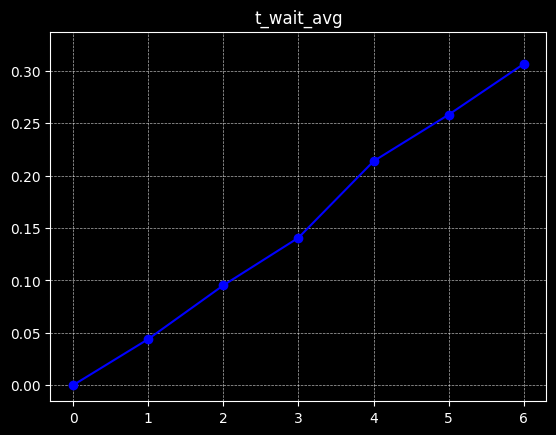

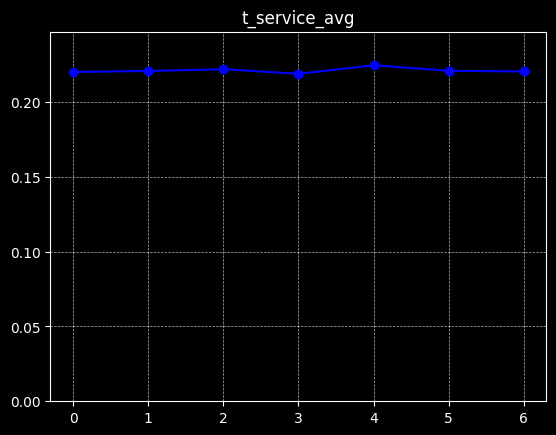

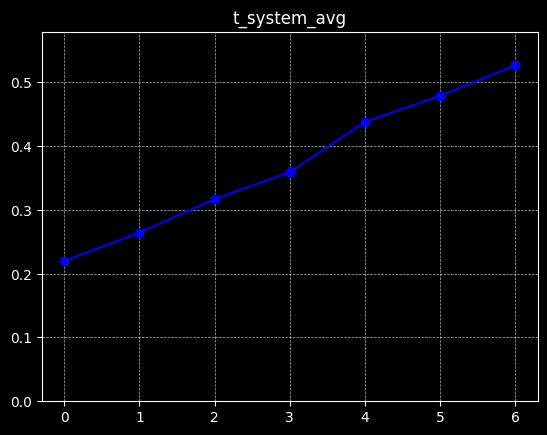

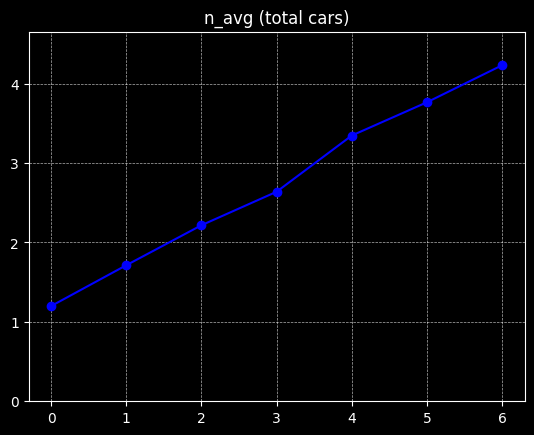

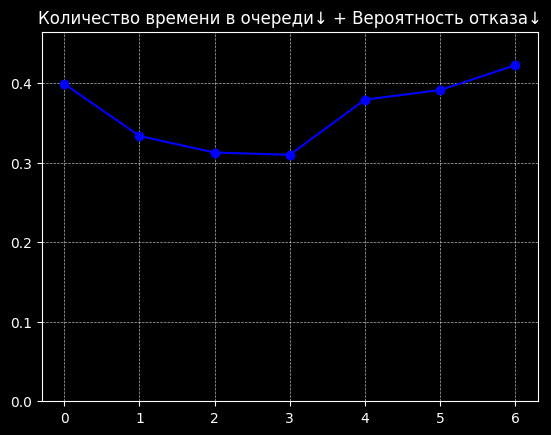

In [27]:
FILENAME = "results.csv"
BASE_DIR = Path.cwd()

def get_data_csv(path):
    if not path.exists():
        print("Файл не найден")
        return []
    try:
        with open(path, "r", newline="") as file:
            reader = csv.reader(file)
            return [*reader]

    except Exception as e:
        print(f"Ошибка работы с файлом {path}. {e}")
        return []
data = {}

path = BASE_DIR / '2_queue_of_car' / 'results_multiple_queues.csv'

data_queue = get_data_csv(path)
for key, *values, _ in data_queue[1:]:
    values = list(map(float, values))
    data[key] = values

data["Количество времени в очереди↓ + Вероятность отказа↓"] = [data["t_wait_avg"][i] + data["p_reject"][i] for i in range(len(data["t_wait_avg"]))]
for key, value in data.items():
    figure, axes = plt.subplots()
    axes.plot([0,1,2,3,4,5,6], value, "ob-")
    axes.set_ylim(bottom=min(0,min(value)-max(value) * 0.05), top=max(value) * 1.1)
    axes.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.7)
    axes.set_xticks([0,1,2,3,4,5,6])
    plt.title(key)
    plt.show()

